# Part 4 — Scaffold-Aware CV & Baseline Models

**Goal:** Establish honest baseline performance using **Butina cluster-based cross-validation**,
then compare the three feature sets from Part 3 side by side.

## Two tasks, one notebook

| Task | Target | Metrics |
|---|---|---|
| **Regression** | `pchembl_value` (continuous) | R², RMSE, MAE, Pearson r |
| **Classification** | `active / inactive` (binary) | AUC-ROC, Balanced Accuracy, MCC, macro-F1 |

## Why Butina CV instead of random split?
Butina clustering groups molecules by **Tanimoto similarity**. Using it for CV means
each test fold contains molecules that are structurally different from the training set —
a more realistic test of whether the model generalises to new chemical space.
A random split would put near-identical molecules in both train and test, inflating R² by 15–30%.

## Why `class_weight='balanced'` instead of SMOTE?
EGFR datasets have more inactive compounds than active ones.
`class_weight='balanced'` penalises errors on the minority class more heavily during training.
SMOTE would synthetically generate new molecules by interpolating fingerprints — that creates
bit patterns that do not correspond to real chemistry, which is inappropriate for QSAR.

**Inputs:** `X_ecfp6.csv`, `X_maccs.csv`, `X_rdkit2d.csv`, `y_pchembl.csv`, `y_binary.csv`  
**Outputs:** `part4_regression_results.csv`, `part4_classification_results.csv`, `best_model.pkl`

---
## 0. Installs & Imports

In [1]:
# Uncomment on first run in Colab:
# !pip install rdkit-pypi scikit-learn

import numpy as np
import pandas as pd
import warnings
import pickle
warnings.filterwarnings('ignore')

# RDKit
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.ML.Cluster import Butina
from scipy.spatial.distance import pdist

# Sklearn — models
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import BaseCrossValidator, cross_validate

# Sklearn — metrics
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    roc_auc_score, balanced_accuracy_score,
    matthews_corrcoef, f1_score, confusion_matrix,
    ConfusionMatrixDisplay
)
from scipy.stats import pearsonr

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
print('All imports OK')

All imports OK


---
## 1. Load Data

In [5]:
# ── Feature matrices (from Part 3) ───────────────────────────────────────────
X_ecfp6_df   = pd.read_csv('../data/processed/X_ecfp6.csv')
X_maccs_df   = pd.read_csv('../data/processed/X_maccs.csv')
X_rdkit2d_df = pd.read_csv('../data/processed/X_rdkit2d.csv')

# ── Target variables ─────────────────────────────────────────────────────────
y_pchembl_df = pd.read_csv('../data/processed/y_pchembl.csv')   # regression
y_binary_df  = pd.read_csv('../data/processed/y_binary.csv')    # classification (active/inactive only)

# ── Molecule objects (needed for Butina clustering) ───────────────────────────
df_clean = pd.read_csv('../data/processed/egfr_bioactivity_cleaned.csv')

print(f'ECFP6 shape   : {X_ecfp6_df.shape}')
print(f'MACCS shape   : {X_maccs_df.shape}')
print(f'RDKit2D shape : {X_rdkit2d_df.shape}')
print(f'y_pchembl     : {y_pchembl_df.shape}')
print(f'y_binary      : {y_binary_df.shape}')

ECFP6 shape   : (9876, 340)
MACCS shape   : (9876, 115)
RDKit2D shape : (9876, 164)
y_pchembl     : (9876, 2)
y_binary      : (8154, 2)


In [6]:
# ── Separate molecule IDs from feature values ─────────────────────────────────
# All feature CSVs have 'molecule_chembl_id' as first column
mol_ids = X_ecfp6_df['molecule_chembl_id']

X_ecfp6   = X_ecfp6_df.drop(columns='molecule_chembl_id').values
X_maccs   = X_maccs_df.drop(columns='molecule_chembl_id').values
X_rdkit2d = X_rdkit2d_df.drop(columns='molecule_chembl_id').values

# ── Regression target: align by molecule_chembl_id ───────────────────────────
y_reg = y_pchembl_df.set_index('molecule_chembl_id').loc[mol_ids, 'pchembl_value'].values

# ── Classification target: active/inactive binary ────────────────────────────
# Binary dataset may have fewer rows (intermediates excluded in Part 1)
# We need to find which indices in our full dataset are active or inactive
y_binary_indexed = y_binary_df.set_index('molecule_chembl_id')
clf_mask = mol_ids.isin(y_binary_indexed.index).values  # boolean mask

X_ecfp6_clf   = X_ecfp6[clf_mask]
X_maccs_clf   = X_maccs[clf_mask]
X_rdkit2d_clf = X_rdkit2d[clf_mask]
mol_ids_clf   = mol_ids[clf_mask].reset_index(drop=True)

label_map = {'active': 1, 'inactive': 0}
y_clf = y_binary_indexed.loc[mol_ids_clf, 'bioactivity_class'].map(label_map).values

print(f'Regression dataset   : {len(y_reg)} compounds')
print(f'Classification dataset: {len(y_clf)} compounds')
print(f'  Active  : {y_clf.sum()}')
print(f'  Inactive: {(y_clf == 0).sum()}')
print(f'  Imbalance ratio: 1 : {(y_clf == 0).sum() / y_clf.sum():.1f}')

Regression dataset   : 9876 compounds
Classification dataset: 8154 compounds
  Active  : 7439
  Inactive: 715
  Imbalance ratio: 1 : 0.1


---
## 2. Butina Cross-Validator

We implement a **sklearn-compatible cross-validator** using Butina clustering.

How it works:
1. Compute Morgan fingerprints for all molecules
2. Build a Tanimoto distance matrix (`1 - Tanimoto similarity`)
3. Cluster with Butina at `sim_cutoff=0.6` (molecules within 60% similarity → same cluster)
4. Distribute clusters across N folds (largest clusters → training; singletons → test)
5. Each fold's test set contains **whole clusters never seen in training**

This is stricter than scaffold split because it uses real pairwise similarity,
not just the core ring system.

In [7]:
# ── Butina helper functions (your code, unchanged) ────────────────────────────

def get_butina_clusters(mols, sim_cutoff=0.6):
    """
    Cluster molecules by Tanimoto similarity using the Butina algorithm.
    Returns a list of tuples: each tuple contains the indices of one cluster.
    """
    fpg  = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    fps  = [fpg.GetFingerprint(mol) for mol in mols]
    dists = pdist(fps, metric='jaccard')        # 1 - Tanimoto
    clusters = Butina.ClusterData(
        dists, len(mols), 1 - sim_cutoff, isDistData=True
    )
    return clusters


def assign_cluster_ids(mols, sim_cutoff=0.6):
    """Return an integer cluster ID for each molecule (same length as mols)."""
    clusters   = get_butina_clusters(mols, sim_cutoff)
    cluster_ids = np.zeros(len(mols), dtype=int)
    for cid, cluster_indices in enumerate(clusters):
        for idx in cluster_indices:
            cluster_ids[idx] = cid
    return cluster_ids


# ── sklearn-compatible CV splitter ───────────────────────────────────────────

class ButinaCrossValidator(BaseCrossValidator):
    """
    K-fold cross-validator that splits by Butina chemical cluster.

    Pass pre-computed cluster_ids as `groups` to .split():
        cv.split(X, y, groups=cluster_ids)

    Each fold's test set contains complete clusters not seen in training.
    Clusters are distributed round-robin across folds by size (largest first),
    so folds are approximately balanced by compound count.
    """

    def __init__(self, n_splits=5):
        self.n_splits = n_splits

    def get_n_splits(self, X=None, y=None, groups=None):
        return self.n_splits

    def _iter_test_masks(self, X=None, y=None, groups=None):
        if groups is None:
            raise ValueError('groups (cluster_ids) must be provided to ButinaCrossValidator.split()')

        n_samples    = len(groups)
        unique_cids  = np.unique(groups)

        # Sort clusters largest → smallest so round-robin distributes evenly
        cluster_sizes = {cid: np.sum(groups == cid) for cid in unique_cids}
        sorted_cids   = sorted(unique_cids, key=lambda c: -cluster_sizes[c])

        # Assign each cluster to a fold (round-robin)
        fold_assignment = {cid: i % self.n_splits
                           for i, cid in enumerate(sorted_cids)}

        # Yield one boolean test mask per fold
        for fold in range(self.n_splits):
            test_mask = np.array(
                [fold_assignment[cid] == fold for cid in groups],
                dtype=bool
            )
            yield test_mask


print('ButinaCrossValidator defined.')

ButinaCrossValidator defined.


In [8]:
# ── Build Mol objects and compute cluster IDs ─────────────────────────────────
# We need cluster IDs for ALL compounds (regression set),
# and a subset for the classification set.

print('Building RDKit Mol objects...')
mols_all = [Chem.MolFromSmiles(smi) for smi in df_clean['canonical_smiles']]

# Filter to only the molecules present in our feature matrices
# (df_clean and feature matrices should be aligned from Part 1→3)
mols_reg = [mols_all[i] for i in range(len(mol_ids))]

print('Running Butina clustering (sim_cutoff=0.6)... this may take ~1-3 min')
cluster_ids_reg = assign_cluster_ids(mols_reg, sim_cutoff=0.6)

# Subset cluster IDs for classification dataset
cluster_ids_clf = cluster_ids_reg[clf_mask]

n_clusters = len(np.unique(cluster_ids_reg))
print(f'\nDone! Found {n_clusters} clusters for {len(mols_reg)} molecules')
print(f'Avg cluster size: {len(mols_reg)/n_clusters:.1f}')

Building RDKit Mol objects...
Running Butina clustering (sim_cutoff=0.6)... this may take ~1-3 min

Done! Found 1026 clusters for 9876 molecules
Avg cluster size: 9.6


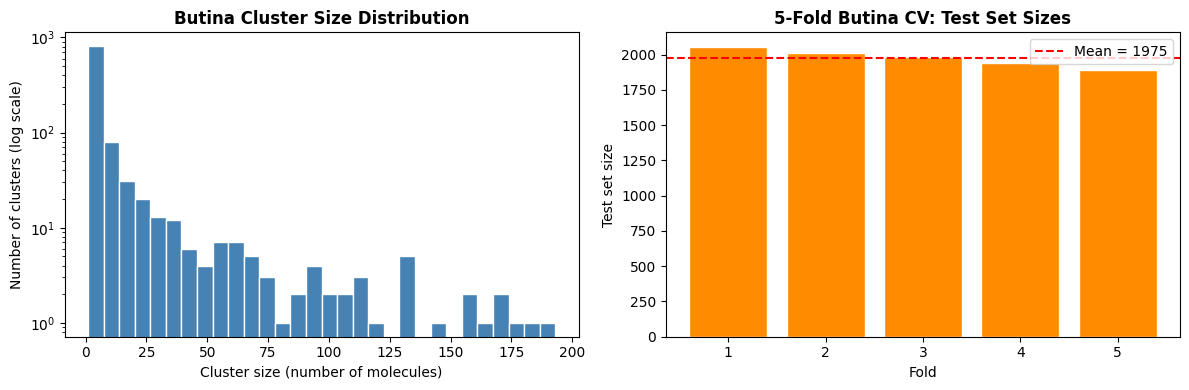

Fold sizes: [2055, 2011, 1980, 1941, 1889]


In [9]:
# ── Visualise cluster size distribution ──────────────────────────────────────
unique, counts = np.unique(cluster_ids_reg, return_counts=True)
sizes = pd.Series(counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Cluster size histogram
axes[0].hist(sizes, bins=30, color='steelblue', edgecolor='white', log=True)
axes[0].set_xlabel('Cluster size (number of molecules)')
axes[0].set_ylabel('Number of clusters (log scale)')
axes[0].set_title('Butina Cluster Size Distribution', fontweight='bold')

# Fold size after 5-fold assignment
cv_temp  = ButinaCrossValidator(n_splits=5)
fold_sizes = []
for train_idx, test_idx in cv_temp.split(X_ecfp6, y_reg, groups=cluster_ids_reg):
    fold_sizes.append(len(test_idx))

axes[1].bar(range(1, 6), fold_sizes, color='darkorange', edgecolor='white')
axes[1].axhline(np.mean(fold_sizes), color='red', linestyle='--', label=f'Mean = {np.mean(fold_sizes):.0f}')
axes[1].set_xlabel('Fold')
axes[1].set_ylabel('Test set size')
axes[1].set_title('5-Fold Butina CV: Test Set Sizes', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../figs/part4_butina_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Fold sizes: {fold_sizes}')

In [11]:
import pandas as pd
from rdkit import Chem

# 1. Cargar tus datos
df = pd.read_csv('tu_archivo.csv')   # Cambia por tu archivo
smiles_list = df['SMILES'].tolist()
activities = df['active'].values   # 0/1

# 2. Convertir a moléculas RDKit (filtrando inválidas)
mols_raw = [Chem.MolFromSmiles(s) for s in smiles_list]
valid_idx = [i for i, mol in enumerate(mols_raw) if mol is not None]
mols = [mols_raw[i] for i in valid_idx]
smiles_list = [smiles_list[i] for i in valid_idx]
activities = [activities[i] for i in valid_idx]

# 3. Asignar cluster IDs (usando tu función)
cluster_ids_reg = assign_cluster_ids(mols, sim_cutoff=0.6)   # o el cutoff que uses

# 4. Generar fingerprints para t-SNE (si no tienes X_ecfp6)
from rdkit.Chem import rdFingerprintGenerator
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
X_ecfp6 = np.array([fpg.GetFingerprintAsNumPy(mol) for mol in mols], dtype=np.float32)

# 5. Si usas y_reg; puedes llamarlo así (actividad)
y_reg = np.array(activities)

FileNotFoundError: [Errno 2] No such file or directory: 'tu_archivo.csv'

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import pairwise_distances
from rdkit import Chem
from rdkit.Chem import Draw, rdFingerprintGenerator

# ------------------ Asegurar que tenemos los objetos necesarios ------------------
# Si no tienes smiles_list, la creamos
if 'smiles_list' not in dir():
    smiles_list = [Chem.MolToSmiles(mol) for mol in mols]

# Si no tienes X_ecfp6 o prefieres usar fingerprints para t-SNE, los generamos
if 'X_ecfp6' not in dir():
    print("Generando fingerprints para t-SNE...")
    fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
    X_ecfp6 = np.array([fpg.GetFingerprintAsNumPy(mol) for mol in mols], dtype=np.float32)

# Recuperar la lista de clústeres (lista de listas de índices) a partir de cluster_ids_reg
def get_clusters_from_ids(cluster_ids):
    """Convierte un array de cluster_ids en lista de listas de índices."""
    unique_cids = np.unique(cluster_ids)
    clusters = []
    for cid in unique_cids:
        clusters.append(np.where(cluster_ids == cid)[0].tolist())
    return clusters

clusters = get_clusters_from_ids(cluster_ids_reg)
print(f"Número de clústeres: {len(clusters)}")

# ------------------ 1. t-SNE sin etiquetas de clúster ------------------
print("Calculando t-SNE (puede llevar unos segundos)...")
# Reducimos con PCA a 50 componentes para acelerar
from sklearn.decomposition import PCA
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(X_ecfp6)
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)
X_tsne = tsne.fit_transform(X_pca)

plt.figure(figsize=(8, 6))
# Coloreamos por actividad (usando y_reg)
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_reg, cmap='coolwarm', s=10, alpha=0.6)
plt.colorbar(scatter, label='Activity')
plt.title('t-SNE projection (colored by activity, no cluster labels)', fontweight='bold')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.savefig('tsne_activity.png', dpi=150)
plt.show()

# ------------------ 2. Distribución de tamaños de clúster ------------------
cluster_sizes = [len(c) for c in clusters]
plt.figure(figsize=(8, 5))
plt.hist(cluster_sizes, bins=30, color='steelblue', edgecolor='white', log=True)
plt.xlabel('Cluster size (number of molecules)')
plt.ylabel('Number of clusters (log scale)')
plt.title('Butina Cluster Size Distribution', fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cluster_size_hist.png', dpi=150)
plt.show()

# ------------------ 3. Violin plot de similitudes intra-clúster ------------------
# Necesitamos los fingerprints de cada molécula (los mismos que se usaron para clusterizar)
fpg = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps_list = [fpg.GetFingerprintAsNumPy(mol) for mol in mols]  # lista de arrays

def intra_cluster_similarities(clusters, fps_list, min_size=2):
    """
    Devuelve una lista de listas: para cada clúster con tamaño >= min_size,
    una lista con todas las similitudes Tanimoto intra-clúster (valores entre 0 y 1).
    """
    intra_all = []
    for idx_list in clusters:
        if len(idx_list) < min_size:
            continue
        cluster_fps = [fps_list[i] for i in idx_list]
        # Matriz de distancias Jaccard -> similitud
        dist_matrix = pairwise_distances(cluster_fps, metric='jaccard')
        sim_matrix = 1 - dist_matrix
        # Extraer triángulo superior sin diagonal
        upper_tri = sim_matrix[np.triu_indices_from(sim_matrix, k=1)]
        intra_all.append(upper_tri)
    return intra_all

intra_sims = intra_cluster_similarities(clusters, fps_list, min_size=2)

# Seleccionar hasta 30 clústeres para el violin plot (los más grandes)
if len(intra_sims) > 30:
    # Ordenamos clústeres por tamaño descendente y cogemos los 30 más grandes
    sizes = [len(c) for c in clusters if len(c) >= 2]
    order = np.argsort(sizes)[::-1][:30]
    intra_sims_plot = [intra_sims[i] for i in order]
    labels = [str(len(clusters[i])) for i in order]  # etiquetas con el tamaño
else:
    intra_sims_plot = intra_sims
    labels = [str(len(c)) for c in clusters if len(c) >= 2]

plt.figure(figsize=(12, 5))
parts = plt.violinplot(intra_sims_plot, positions=range(len(intra_sims_plot)),
                       showmeans=True, showmedians=True, showextrema=False)
# Personalizar colores
for pc in parts['bodies']:
    pc.set_facecolor('#1b9e77')
    pc.set_alpha(0.6)
parts['cmeans'].set_color('red')
parts['cmedians'].set_color('blue')
plt.xticks(range(len(intra_sims_plot)), labels, rotation=90)
plt.xlabel('Cluster (labeled by size)')
plt.ylabel('Intra-cluster Tanimoto similarity')
plt.title('Intra-cluster Similarity Distribution (clusters with ≥2 molecules)', fontweight='bold')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('violin_intra_similarity.png', dpi=150)
plt.show()

# ------------------ 4. Cinco centroides más representativos (globales) ------------------
def get_centroid_indices(clusters, fps_list):
    """Devuelve el índice de la molécula centroide (mayor similitud media) para cada clúster."""
    centroids = []
    for idx_list in clusters:
        if len(idx_list) == 0:
            continue
        if len(idx_list) == 1:
            centroids.append(idx_list[0])
            continue
        cluster_fps = [fps_list[i] for i in idx_list]
        sim_matrix = 1 - pairwise_distances(cluster_fps, metric='jaccard')
        mean_sim = np.mean(sim_matrix, axis=1)
        best_local = np.argmax(mean_sim)
        centroids.append(idx_list[best_local])
    return centroids

centroid_indices = get_centroid_indices(clusters, fps_list)

# Ordenar clústeres por tamaño (grandes a pequeños) y tomar los 5 primeros centroides
cluster_sizes_with_centroid = [(len(clusters[i]), centroid_indices[i]) for i in range(len(clusters))]
cluster_sizes_with_centroid.sort(reverse=True, key=lambda x: x[0])
top5_centroids = [idx for size, idx in cluster_sizes_with_centroid[:5]]

# Mostrar estructura de los 5 clústeres más grandes (centroides)
top5_mols = [mols[idx] for idx in top5_centroids]
top5_smiles = [smiles_list[idx] for idx in top5_centroids]
# Encontrar a qué clúster pertenece cada centroide
top5_cluster_ids = []
for idx in top5_centroids:
    cid = cluster_ids_reg[idx]
    size = np.sum(cluster_ids_reg == cid)
    top5_cluster_ids.append(f"Cluster {cid} (size={size})")

legends = [f"{cid}\n{smiles[:40]}" for cid, smiles in zip(top5_cluster_ids, top5_smiles)]
img_top5 = Draw.MolsToGridImage(top5_mols, legends=legends, molsPerRow=5, subImgSize=(250, 200))
img_top5.show()
# Guardar
img_top5.save('top5_representative_centroids.png')

print("Los 5 clústeres más grandes y sus centroides representativos se han guardado.")

# ------------------ 5. Centroides más activos de un clúster elegido ------------------
# Elige aquí el ID del clúster que te interesa (lo puedes cambiar manualmente)
selected_cluster_id = 0  # <--- CAMBIA este número por el clúster que quieras explorar
print(f"\nMostrando las 5 moléculas más activas del clúster {selected_cluster_id}")

# Obtener índices del clúster seleccionado
mask = cluster_ids_reg == selected_cluster_id
indices_in_cluster = np.where(mask)[0]
if len(indices_in_cluster) == 0:
    print(f"⚠️ El clúster {selected_cluster_id} no existe. Elige otro ID.")
else:
    # Obtener actividades de esas moléculas
    acts_in_cluster = y_reg[indices_in_cluster]
    # Ordenar por actividad descendente (si es binaria, las activas primero; si continua, las más altas)
    sorted_order = np.argsort(acts_in_cluster)[::-1]
    top_active_indices = indices_in_cluster[sorted_order][:5]
    
    # Mostrar moléculas
    active_mols = [mols[i] for i in top_active_indices]
    active_smiles = [smiles_list[i] for i in top_active_indices]
    active_values = [y_reg[i] for i in top_active_indices]
    legends_active = [f"Activity={act:.3f}\n{smiles[:40]}" for act, smiles in zip(active_values, active_smiles)]
    
    img_active = Draw.MolsToGridImage(active_mols, legends=legends_active, molsPerRow=5, subImgSize=(250, 200))
    img_active.show()
    img_active.save(f'cluster_{selected_cluster_id}_top_active.png')

NameError: name 'mols' is not defined

---
## 3. Evaluation Helper Functions

Two functions that compute all metrics for each task in one call.

In [ ]:
def regression_metrics(y_true, y_pred):
    """Compute all regression metrics at once."""
    r2   = r2_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r, _ = pearsonr(y_true, y_pred)
    return {'R2': r2, 'RMSE': rmse, 'MAE': mae, 'Pearson_r': r}


def classification_metrics(y_true, y_pred, y_prob=None):
    """
    Compute all classification metrics at once.
    y_prob: predicted probability for class=1 (needed for AUC).
    """
    auc  = roc_auc_score(y_true, y_prob) if y_prob is not None else np.nan
    ba   = balanced_accuracy_score(y_true, y_pred)
    mcc  = matthews_corrcoef(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, average='macro')
    return {'AUC': auc, 'BalancedAcc': ba, 'MCC': mcc, 'MacroF1': f1}


def run_butina_cv_regression(model, X, y, cluster_ids, n_splits=5):
    """
    Run Butina CV for a regression model.
    Returns a DataFrame with per-fold metrics + mean ± std row.
    """
    cv = ButinaCrossValidator(n_splits=n_splits)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups=cluster_ids), start=1
    ):
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])
        m = regression_metrics(y[test_idx], y_pred)
        m['Fold'] = fold
        fold_results.append(m)

    df_folds = pd.DataFrame(fold_results).set_index('Fold')

    # Summary row
    mean_row = df_folds.mean().rename('mean')
    std_row  = df_folds.std().rename('std')
    df_summary = pd.concat([df_folds, mean_row.to_frame().T, std_row.to_frame().T])
    return df_summary


def run_butina_cv_classification(model, X, y, cluster_ids, n_splits=5):
    """
    Run Butina CV for a classification model.
    Returns a DataFrame with per-fold metrics + mean ± std row.
    """
    cv = ButinaCrossValidator(n_splits=n_splits)
    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(
        cv.split(X, y, groups=cluster_ids), start=1
    ):
        model.fit(X[train_idx], y[train_idx])
        y_pred = model.predict(X[test_idx])
        y_prob = model.predict_proba(X[test_idx])[:, 1]
        m = classification_metrics(y[test_idx], y_pred, y_prob)
        m['Fold'] = fold
        fold_results.append(m)

    df_folds = pd.DataFrame(fold_results).set_index('Fold')
    mean_row = df_folds.mean().rename('mean')
    std_row  = df_folds.std().rename('std')
    df_summary = pd.concat([df_folds, mean_row.to_frame().T, std_row.to_frame().T])
    return df_summary


print('Evaluation functions defined.')

---
## 4. Baseline: Random Forest — Regression

We run each of the three feature sets through the same RF regressor
under identical Butina 5-fold CV conditions.
This gives a clean **feature ablation** table.

In [ ]:
rf_reg = RandomForestRegressor(
    n_estimators=500,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_sets_reg = {
    'ECFP6'   : X_ecfp6,
    'MACCS'   : X_maccs,
    'RDKit_2D': X_rdkit2d,
}

reg_results = {}

for name, X_feat in feature_sets_reg.items():
    print(f'Running regression CV with {name} ({X_feat.shape[1]} features)...')
    res = run_butina_cv_regression(
        model=rf_reg, X=X_feat, y=y_reg,
        cluster_ids=cluster_ids_reg, n_splits=5
    )
    reg_results[name] = res
    mean = res.loc['mean']
    std  = res.loc['std']
    print(f'  R²={mean.R2:.3f}±{std.R2:.3f}  RMSE={mean.RMSE:.3f}±{std.RMSE:.3f}  '
          f'MAE={mean.MAE:.3f}  r={mean.Pearson_r:.3f}\n')

In [ ]:
# ── Regression results table ──────────────────────────────────────────────────
reg_summary = pd.DataFrame([
    {
        'Feature set': name,
        'n_features' : feature_sets_reg[name].shape[1],
        'R² mean'    : f"{reg_results[name].loc['mean','R2']:.3f}",
        'R² std'     : f"±{reg_results[name].loc['std','R2']:.3f}",
        'RMSE'       : f"{reg_results[name].loc['mean','RMSE']:.3f}",
        'MAE'        : f"{reg_results[name].loc['mean','MAE']:.3f}",
        'Pearson r'  : f"{reg_results[name].loc['mean','Pearson_r']:.3f}",
    }
    for name in feature_sets_reg
])

# Literature benchmark row
reg_summary.loc[len(reg_summary)] = [
    'SVR (Vignaux 2023)', '—', '0.810', '—', '0.730', '0.550', '0.760'
]

print('=== REGRESSION RESULTS (Butina 5-fold CV) ===')
print(reg_summary.to_string(index=False))
reg_summary.to_csv('part4_regression_results.csv', index=False)

---
## 5. Baseline: Random Forest — Classification

**`class_weight='balanced'`** makes the model pay more attention to the minority class
(active compounds) during training. Without this, a model can achieve high accuracy
by simply predicting "inactive" for everything — which is useless for drug discovery.

**MCC (Matthews Correlation Coefficient)** is the single most honest metric for
imbalanced classification. It ranges from -1 to +1, where +1 = perfect, 0 = random.

In [ ]:
rf_clf = RandomForestClassifier(
    n_estimators=500,
    class_weight='balanced',   # handles active/inactive imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_sets_clf = {
    'ECFP6'   : X_ecfp6_clf,
    'MACCS'   : X_maccs_clf,
    'RDKit_2D': X_rdkit2d_clf,
}

clf_results = {}

for name, X_feat in feature_sets_clf.items():
    print(f'Running classification CV with {name} ({X_feat.shape[1]} features)...')
    res = run_butina_cv_classification(
        model=rf_clf, X=X_feat, y=y_clf,
        cluster_ids=cluster_ids_clf, n_splits=5
    )
    clf_results[name] = res
    mean = res.loc['mean']
    std  = res.loc['std']
    print(f'  AUC={mean.AUC:.3f}±{std.AUC:.3f}  BalAcc={mean.BalancedAcc:.3f}  '
          f'MCC={mean.MCC:.3f}  F1={mean.MacroF1:.3f}\n')

In [ ]:
# ── Classification results table ──────────────────────────────────────────────
clf_summary = pd.DataFrame([
    {
        'Feature set'  : name,
        'n_features'   : feature_sets_clf[name].shape[1],
        'AUC mean'     : f"{clf_results[name].loc['mean','AUC']:.3f}",
        'AUC std'      : f"±{clf_results[name].loc['std','AUC']:.3f}",
        'BalancedAcc'  : f"{clf_results[name].loc['mean','BalancedAcc']:.3f}",
        'MCC'          : f"{clf_results[name].loc['mean','MCC']:.3f}",
        'Macro F1'     : f"{clf_results[name].loc['mean','MacroF1']:.3f}",
    }
    for name in feature_sets_clf
])

# Literature benchmark (DeepEGFR uses F1 ~0.94 for GNN — much harder to match)
clf_summary.loc[len(clf_summary)] = [
    'GNN (DeepEGFR 2025)', '—', '—', '—', '—', '—', '~0.94'
]

print('=== CLASSIFICATION RESULTS (Butina 5-fold CV) ===')
print(clf_summary.to_string(index=False))
clf_summary.to_csv('part4_classification_results.csv', index=False)

---
## 6. Key Figures

In [ ]:
# ── Figure 1: Experimental vs Predicted pIC50 (best feature set, last fold) ──
# Re-run the last fold of the best-performing feature set to get y_test / y_pred

best_feat_name = max(
    reg_results,
    key=lambda n: float(reg_results[n].loc['mean', 'R2'])
)
X_best = feature_sets_reg[best_feat_name]

cv = ButinaCrossValidator(n_splits=5)
splits = list(cv.split(X_best, y_reg, groups=cluster_ids_reg))
train_idx, test_idx = splits[-1]   # last fold for the plot

rf_reg.fit(X_best[train_idx], y_reg[train_idx])
y_pred_plot = rf_reg.predict(X_best[test_idx])
y_test_plot = y_reg[test_idx]

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test_plot, y_pred_plot, alpha=0.4, s=20, color='steelblue')
lims = [min(y_test_plot.min(), y_pred_plot.min()) - 0.3,
        max(y_test_plot.max(), y_pred_plot.max()) + 0.3]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y=x)')
r2 = r2_score(y_test_plot, y_pred_plot)
ax.set_xlabel('Experimental pChEMBL', fontsize=12)
ax.set_ylabel('Predicted pChEMBL', fontsize=12)
ax.set_title(f'RF Regression — {best_feat_name} (Butina CV, fold 5)\nR² = {r2:.3f}',
             fontweight='bold')
ax.legend(fontsize=9)
ax.set_xlim(lims); ax.set_ylim(lims)
plt.tight_layout()
plt.savefig('part4_regression_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Figure 2: R² per fold — shows variance across folds ──────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

colors = ['steelblue', 'darkorange', 'green']
fold_labels = [1, 2, 3, 4, 5]

for ax, (metric, ylabel, title) in zip(
    axes,
    [('R2', 'R²', 'Regression R² per fold'),
     ('AUC', 'AUC-ROC', 'Classification AUC per fold')]
):
    if metric == 'R2':
        results_dict = reg_results
    else:
        results_dict = clf_results

    for (name, res), color in zip(results_dict.items(), colors):
        fold_vals = res.loc[[1,2,3,4,5], metric].astype(float)
        ax.plot(fold_labels, fold_vals, 'o-', color=color,
                label=name, linewidth=1.5, markersize=6)
        mean_val = res.loc['mean', metric]
        ax.axhline(mean_val, color=color, linestyle='--', alpha=0.4, linewidth=1)

    ax.set_xlabel('Fold')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xticks(fold_labels)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('part4_cv_folds.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Figure 3: Confusion matrix for best classification feature set ─────────────
best_clf_feat = max(
    clf_results,
    key=lambda n: float(clf_results[n].loc['mean', 'AUC'])
)
X_best_clf = feature_sets_clf[best_clf_feat]

cv_clf = ButinaCrossValidator(n_splits=5)
all_y_true, all_y_pred = [], []

for train_idx, test_idx in cv_clf.split(X_best_clf, y_clf, groups=cluster_ids_clf):
    rf_clf.fit(X_best_clf[train_idx], y_clf[train_idx])
    all_y_true.extend(y_clf[test_idx])
    all_y_pred.extend(rf_clf.predict(X_best_clf[test_idx]))

cm = confusion_matrix(all_y_true, all_y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Inactive (0)', 'Active (1)']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — RF + {best_clf_feat}\n(all 5 Butina CV folds combined)',
             fontweight='bold')
plt.tight_layout()
plt.savefig('part4_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Save Best Model

In [ ]:
# Train the best regressor on ALL data (no held-out set) for Part 6 SHAP
# Note: this model is for interpretation only — performance was already
# measured honestly via CV above. Do NOT evaluate it on the training data.

best_X_all = feature_sets_reg[best_feat_name]   # full dataset
rf_reg_final = RandomForestRegressor(
    n_estimators=500, random_state=RANDOM_STATE, n_jobs=-1
)
rf_reg_final.fit(best_X_all, y_reg)

with open('best_rf_regressor.pkl', 'wb') as f:
    pickle.dump(rf_reg_final, f)

# Save which feature set was best (needed in Part 5/6)
with open('best_feature_set.txt', 'w') as f:
    f.write(best_feat_name)

# Save cluster IDs (needed in Part 5 for consistent CV)
np.save('butina_cluster_ids_reg.npy', cluster_ids_reg)
np.save('butina_cluster_ids_clf.npy', cluster_ids_clf)

print(f'Saved best_rf_regressor.pkl  (trained on {best_feat_name}, {len(y_reg)} compounds)')
print(f'Saved butina_cluster_ids_reg.npy  ({len(cluster_ids_reg)} entries)')
print(f'Saved butina_cluster_ids_clf.npy  ({len(cluster_ids_clf)} entries)')

---
## Summary

### What this notebook produced
- **Butina 5-fold CV** results for 3 feature sets × 2 tasks (regression + classification)
- A feature ablation table ready for the README
- Three key figures: scatter plot, per-fold CV stability, confusion matrix
- `best_rf_regressor.pkl` + `butina_cluster_ids.npy` for Parts 5 and 6

### What comes next (Part 5)
- Replace the default RF hyperparameters with **Optuna-tuned** ones
- Add **XGBoost** and **SVR** to the comparison
- All models use the same Butina CV indices saved here → apples-to-apples comparison

### Why the R² here may be lower than papers
Butina CV tests on structurally novel molecules — this is the scientifically honest result.
Papers using random splits or no CV often report R² 0.1–0.3 higher than this.
A lower but honest R² is more valuable for a portfolio than an inflated one.